# Importing Necessary Dependencies

In [1]:
# !uv pip uninstall floris
# !uv add floris

In [2]:
import pandas as pd
import floris
from floris import *
from matplotlib import pyplot as plt
import numpy as np
import floris.flow_visualization as flowviz

import warnings
warnings.filterwarnings("ignore")

# Setting Up Turbine Data

In [3]:
Name = "IEA 3.4MW Reference"
Rated_Power = 3370
Rated_Wind_Speed = 9.8
Cut_in_Wind_Speed = 3
Cut_out_Wind_Speed = 25
Rotor_Diameter = 130
Hub_Height = 120

# 1. Printing Data for Editing Turbine Yaml

In [4]:
db = r"/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/IEA_Reference_3.4MW_130 (1).csv"

In [5]:
data = pd.read_csv(db)

data.head()

,Wind Speed [m/s],Power [kW],Cp [-],Thrust [kN],Ct [-]
0,3.0000,51.620327,0.2368,59.159022,0.8140
1,3.5392,123.368159,0.3446,81.337534,0.8042
2,4.0485,213.241509,0.3980,105.641598,0.7982
3,4.5267,318.837998,0.4257,131.466695,0.7945
4,4.9730,435.956487,0.4390,158.022534,0.7913


In [6]:
# [print(i) for i in data["Ct [-]"]]
# [print(i) for i in data["Wind Speed [m/s]"]]
[print(i) for i in data["Power [kW]"]]

[]

51.6203274
123.3681588
213.241509
318.837998
435.9564867
560.8983052
688.906312
819.1257759
949.7236726
1075.927005
1193.682699
1299.172102
1388.952513
1460.081742
1510.222643
1537.725022
1541.682933
1561.569465
1605.876078
1675.862931
1773.500601
1901.498529
2063.341406
2263.331677
2506.635948
2799.332771
3148.458978
3370.0
3370.000035
3370.000717
3370.000086
3370.000018
3370.011453
3370.00003
3370.001728
3370.008641
3370.033669
3370.000061
3370.000238
3370.001502
3370.002288
3370.002284
3370.018233
3370.034011
3370.004589
3369.999956
3370.000667
3370.003948
3370.00009
3370.104925


[]

# Creating Floris Model Object

In [7]:
x = [0, 5*Rotor_Diameter, 10*Rotor_Diameter]
y = [0,0,0]
wd = [270]
ws = [8]
ti = [0.06]

ws_array = np.linspace(3,44,25)

windshear = 0.14

yaw_angles = np.tile(np.linspace(-30, 30, 30)[:, None], (1, 3))

In [8]:
# fmodel_gauss = FlorisModel('/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/gch.yaml')
fmodel = FlorisModel('/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/jensen.yaml')
fmodel.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti, wind_shear=windshear
           )

# 2. Check the turbine characteristics

## Config for Testing Turbine

In [9]:
x = [0]
y = [0]
wd = [270]
ws = [7.5]
ti = [0.06]

ws_array = np.arange(0.1, 30.1, 0.2)
wd_array = 270.0 * np.ones_like(ws_array)
turbulence_intensities = 0.06 * np.ones_like(ws_array)
yaw_angles = np.linspace(-30, 30, 60)

yaw_angles = np.linspace(-30,30,60)

In [10]:
fmodel.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,turbulence_intensities=ti)

## Actually Testing the Turbine

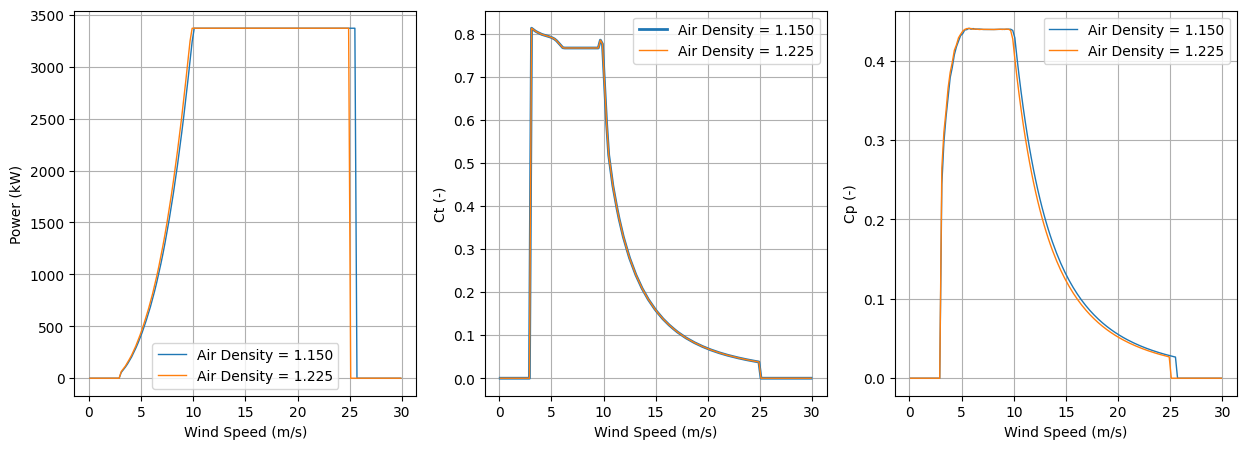

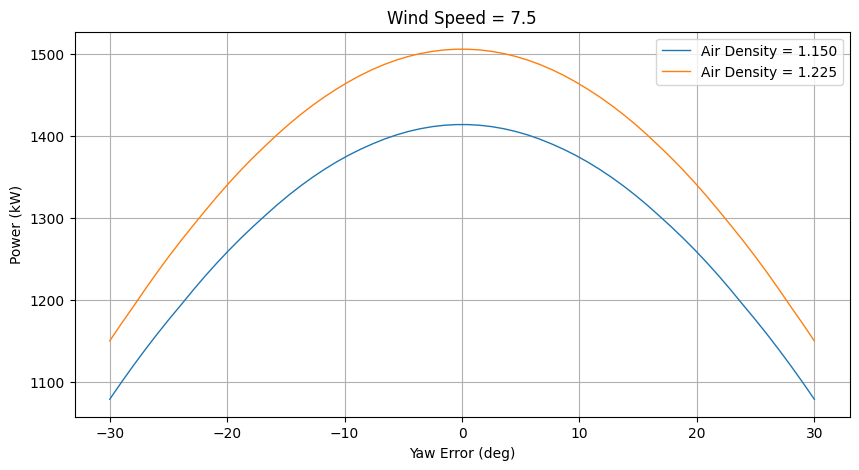

In [11]:


# Set t as the turbine
fmodel.reset_operation() # Remove any previously applied yaw angles

# Create a figure
fig, axarr = plt.subplots(1, 3, figsize=(15, 5))
    
fig_2,axarr_2 = plt.subplots(1, 1, figsize=(10, 5))

# Try a few density
for density in [1.15, 1.225]:
    fmodel.set(air_density=density)

    # POWER CURVE
    ax = axarr[0]
    fmodel.set(
        wind_speeds=ws_array,
        wind_directions=wd_array,
        turbulence_intensities=turbulence_intensities,
    )
    fmodel.reset_operation() # Remove any previously applied yaw angles
    fmodel.run()
    turbine_powers = fmodel.get_turbine_powers().flatten() / 1e3
    ax.plot(ws_array, turbine_powers, label="Air Density = %.3f" % density, lw=1)
    ax.grid(True)
    ax.legend()
    ax.set_xlabel("Wind Speed (m/s)")
    ax.set_ylabel("Power (kW)")
    
    ax = axarr[1]
    
    turbine_ct = fmodel.get_turbine_thrust_coefficients().flatten()
    
    if density == 1.15:
        ax.plot(ws_array, turbine_ct, label="Air Density = %.3f" % density, lw=2)
    else:
        ax.plot(ws_array, turbine_ct, label="Air Density = %.3f" % density, lw=1)
    ax.grid(True)
    ax.legend()
    ax.set_xlabel("Wind Speed (m/s)")
    ax.set_ylabel("Ct (-)")
    
    
    ax = axarr[2]
    
    cp = fmodel.get_turbine_powers().squeeze() / (0.5 * density * (np.pi*((Rotor_Diameter/2)**2)) * ws_array**3)
    
    ax.plot(ws_array, cp, label="Air Density = %.3f" % density, lw=1)
    ax.grid(True)
    ax.legend()
    ax.set_xlabel("Wind Speed (m/s)")
    ax.set_ylabel("Cp (-)")

    # Power loss to yaw, try a range of yaw angles
    ax = axarr_2

    fmodel.set(
        wind_speeds=ws,
        wind_directions=[270.0],
        turbulence_intensities=[0.06],
    )
    yaw_result = []
    for yaw in yaw_angles:
        fmodel.set(yaw_angles=np.array([[yaw]]))
        fmodel.run()
        turbine_powers = fmodel.get_turbine_powers().flatten() / 1e3
        yaw_result.append(turbine_powers[0])
        
    ax.plot(yaw_angles, yaw_result, label="Air Density = %.3f" % density, lw=1)
    ax.grid(True)
    ax.legend()
    ax.set_xlabel("Yaw Error (deg)")
    ax.set_ylabel("Power (kW)")
    ax.set_title("Wind Speed = %.1f" % ws[0])

plt.show()


# 3. Visualize the Wind Farm Flow Field

## 0 Deg

### Setting Up Wind Farm

In [12]:
x = [0, 5*Rotor_Diameter, 10*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [0]
ti = [0.06]

In [13]:
fmodel = FlorisModel('/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/jensen.yaml')
fmodel.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti, wind_shear=windshear
           )

### Visualization

<Axes: title={'center': 'Spanwise profile'}>

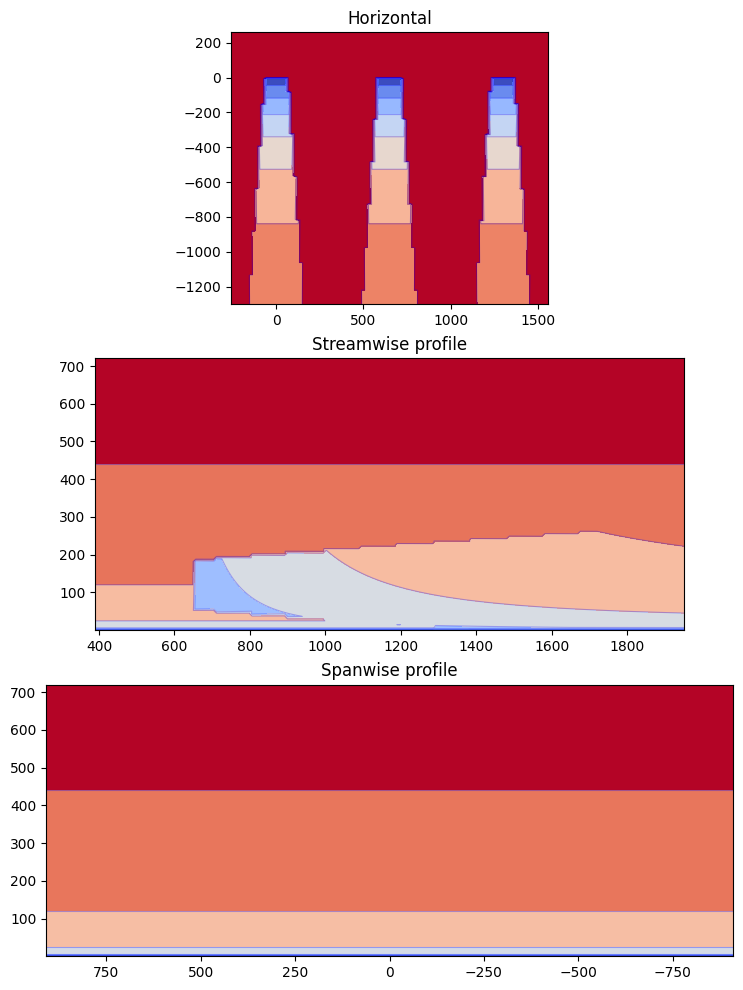

In [14]:
# Using the FlorisModel functions for generating plots, run FLORIS
# and extract 2D planes of data.
horizontal_plane = fmodel.calculate_horizontal_plane(x_resolution=200, y_resolution=100, height=Hub_Height)
y_plane = fmodel.calculate_y_plane(x_resolution=200, z_resolution=100, crossstream_dist=0.0)
cross_plane = fmodel.calculate_cross_plane(
    y_resolution=100, z_resolution=100, downstream_dist=500.0
)

# Create the plots
fig, ax_list = plt.subplots(3, 1, figsize=(10, 12))
ax_list = ax_list.flatten()
flowviz.visualize_cut_plane(horizontal_plane, ax=ax_list[0], title="Horizontal")
flowviz.visualize_cut_plane(y_plane, ax=ax_list[1], title="Streamwise profile")
flowviz.visualize_cut_plane(cross_plane, ax=ax_list[2], title="Spanwise profile")

## 270 Deg

### Setting Up Wind Farm

In [15]:
x = [0, 5*Rotor_Diameter, 10*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [270]
ti = [0.06]

In [16]:
fmodel = FlorisModel('/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/jensen.yaml')
fmodel.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti, wind_shear=windshear
           )

### Visualization

<Axes: title={'center': 'Spanwise profile'}>

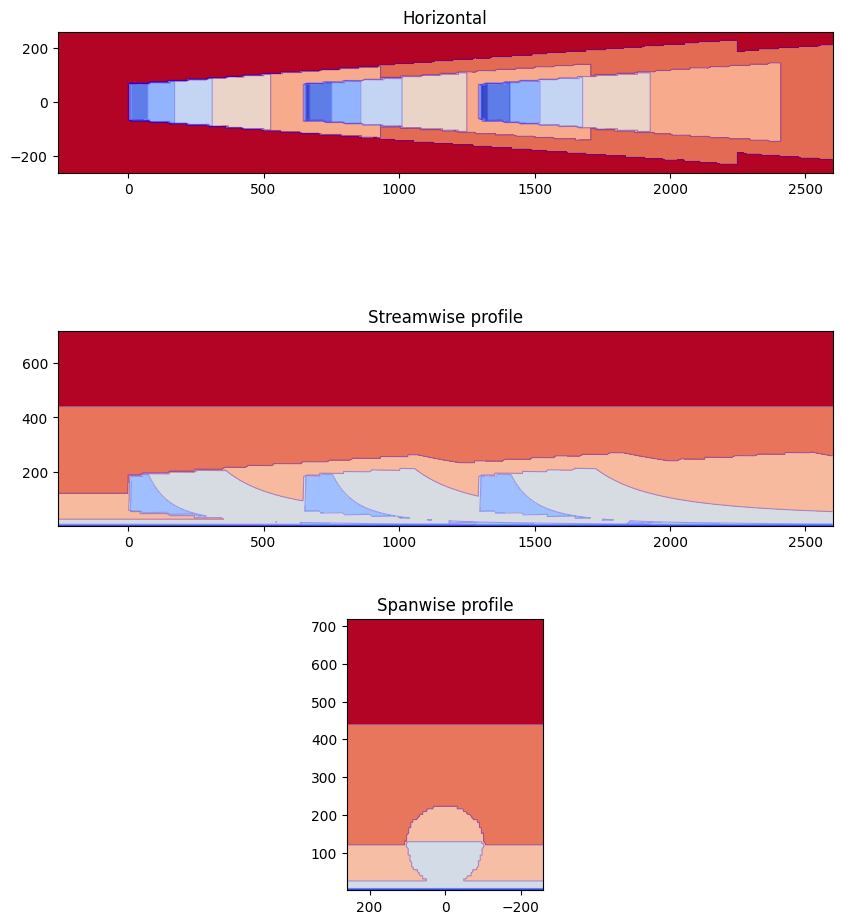

In [17]:
# Using the FlorisModel functions for generating plots, run FLORIS
# and extract 2D planes of data.
horizontal_plane = fmodel.calculate_horizontal_plane(x_resolution=200, y_resolution=100, height=Hub_Height)
y_plane = fmodel.calculate_y_plane(x_resolution=200, z_resolution=100, crossstream_dist=0.0)
cross_plane = fmodel.calculate_cross_plane(
    y_resolution=100, z_resolution=100, downstream_dist=500.0
)

# Create the plots
fig, ax_list = plt.subplots(3, 1, figsize=(10, 12))
ax_list = ax_list.flatten()
flowviz.visualize_cut_plane(horizontal_plane, ax=ax_list[0], title="Horizontal")
flowviz.visualize_cut_plane(y_plane, ax=ax_list[1], title="Streamwise profile")
flowviz.visualize_cut_plane(cross_plane, ax=ax_list[2], title="Spanwise profile")

# 4. Calculating Jensen Wake Power

## 0 Deg (No Wake Case)

In [18]:
x = [0, 5*Rotor_Diameter, 10*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [0]
ti = [0.06]

In [19]:
fmodel.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti, wind_shear=windshear
           )

In [20]:

fmodel.run()

turbine_power = fmodel.get_turbine_powers()[0]/1e3

farm_power = fmodel.get_farm_power()[0]/1e3

turbine_power_hand = [1515.1511666703539, 1515.1511666703539, 1515.1511666703539]

farm_power_hand = sum(turbine_power_hand)

# print(turbine_powers.shape)

print("\nAbsolute Power [kW]")
print("Floris \t \t \tHand Calculations \tError")
print(f"T1: {turbine_power[0]:.1f} \t \t" f"T1: {turbine_power_hand[0]:.1f} \t \t" f"T1: {100*((turbine_power_hand[0]-turbine_power[0])/(turbine_power_hand[0])):.3f}%")
print(f"T2: {turbine_power[1]:.1f} \t \t" f"T2: {turbine_power_hand[1]:.1f} \t \t" f"T2: {100*((turbine_power_hand[1]-turbine_power[1])/(turbine_power_hand[1])):.3f}%")
print(f"T3: {turbine_power[2]:.1f} \t \t" f"T3: {turbine_power_hand[2]:.1f} \t \t" f"T3: {100*((turbine_power_hand[2]-turbine_power[2])/(turbine_power_hand[2])):.3f}%")
print(f"Farm: {farm_power:.1f} \t \t" f"Farm: {farm_power_hand:.1f} \t \t" f"Farm: {100*((farm_power_hand-farm_power)/(farm_power_hand)):.3f}%")



Absolute Power [kW]
Floris 	 	 	Hand Calculations 	Error
T1: 1505.9 	 	T1: 1515.2 	 	T1: 0.610%
T2: 1505.9 	 	T2: 1515.2 	 	T2: 0.610%
T3: 1505.9 	 	T3: 1515.2 	 	T3: 0.610%
Farm: 4517.7 	 	Farm: 4545.5 	 	Farm: 0.610%


## 270 Deg (Wake Case)

In [21]:
x = [0, 5*Rotor_Diameter, 10*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [270]
ti = [0.06]

In [22]:
fmodel.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti, wind_shear=windshear
           )

In [23]:
fmodel.run()

turbine_power = fmodel.get_turbine_powers()[0]/1e3

farm_power = fmodel.get_farm_power()[0]/1e3

turbine_power_hand = [1515.1511666703539, 872.3624730957515, 812.4161478232323]

farm_power_hand = sum(turbine_power_hand)

print("\nAbsolute Power [kW]")
print("Floris \t \t \tHand Calculations \tError")
print(f"T1: {turbine_power[0]:.1f} \t \t" f"T1: {turbine_power_hand[0]:.1f} \t \t" f"T1: {100*((turbine_power_hand[0]-turbine_power[0])/(turbine_power_hand[0])):.3f}%")
print(f"T2: {turbine_power[1]:.1f} \t \t" f"T2: {turbine_power_hand[1]:.1f} \t \t" f"T2: {100*((turbine_power_hand[1]-turbine_power[1])/(turbine_power_hand[1])):.3f}%")
print(f"T3: {turbine_power[2]:.1f} \t \t" f"T3: {turbine_power_hand[2]:.1f} \t \t" f"T3: {100*((turbine_power_hand[2]-turbine_power[2])/(turbine_power_hand[2])):.3f}%")
print(f"Farm: {farm_power:.1f} \t \t" f"Farm: {farm_power_hand:.1f} \t \t" f"Farm: {100*((farm_power_hand-farm_power)/(farm_power_hand)):.3f}%")



Absolute Power [kW]
Floris 	 	 	Hand Calculations 	Error
T1: 1505.9 	 	T1: 1515.2 	 	T1: 0.610%
T2: 866.6 	 	T2: 872.4 	 	T2: 0.665%
T3: 807.3 	 	T3: 812.4 	 	T3: 0.630%
Farm: 3179.8 	 	Farm: 3199.9 	 	Farm: 0.630%


# 5. Difference Between 5D and 10D

## No Wake Case

## Note:

Because at 0 degree, there is no wake there will be 0 difference between 5D and 10D.

### Calculating for 5D

In [24]:
x = [0, 5*Rotor_Diameter, 10*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [0]
ti = [0.06]

fmodel.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti, wind_shear=windshear
           )

fmodel.run()

turbine_power_5D = fmodel.get_turbine_powers()[0]/1e3

farm_power_5D = fmodel.get_farm_power()[0]/1e3

### Calculating for 10D

In [25]:
x = [0, 10*Rotor_Diameter, 20*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [0]
ti = [0.06]

fmodel.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti, wind_shear=windshear
           )

fmodel.run()

turbine_power_10D = fmodel.get_turbine_powers()[0]/1e3

farm_power_10D = fmodel.get_farm_power()[0]/1e3

### Difference 

In [26]:
print("Difference between 5D and 10D")
print("5D \t\t\t10D \t\t\tRelative Difference wrt 5D")

print(f"T1: {turbine_power_5D[0]:.1f} \t\t"
      f"T1: {turbine_power_10D[0]:.1f} \t\t"
      f"T1: {100*((turbine_power_10D[0]-turbine_power_5D[0])/turbine_power_5D[0]):.3f}%")

print(f"T2: {turbine_power_5D[1]:.1f} \t\t"
      f"T2: {turbine_power_10D[1]:.1f} \t\t"
      f"T2: {100*((turbine_power_10D[1]-turbine_power_5D[1])/turbine_power_5D[1]):.3f}%")

print(f"T3: {turbine_power_5D[2]:.1f} \t\t"
      f"T3: {turbine_power_10D[2]:.1f} \t\t"
      f"T3: {100*((turbine_power_10D[2]-turbine_power_5D[2])/turbine_power_5D[2]):.3f}%")

print(f"Farm: {farm_power_5D:.1f} \t\t"
      f"Farm: {farm_power_10D:.1f} \t\t"
      f"Farm: {100*((farm_power_10D-farm_power_5D)/farm_power_5D):.3f}%")

Difference between 5D and 10D
5D 			10D 			Relative Difference wrt 5D
T1: 1505.9 		T1: 1505.9 		T1: 0.000%
T2: 1505.9 		T2: 1505.9 		T2: 0.000%
T3: 1505.9 		T3: 1505.9 		T3: 0.000%
Farm: 4517.7 		Farm: 4517.7 		Farm: 0.000%


## Wake Case

## Note:

Switching to 270 degree, to force wake interaction.

### Calculating for 5D

In [27]:
x = [0, 5*Rotor_Diameter, 10*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [270]
ti = [0.06]

fmodel.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti, wind_shear=windshear
           )

fmodel.run()

turbine_power_5D = fmodel.get_turbine_powers()[0]/1e3

farm_power_5D = fmodel.get_farm_power()[0]/1e3

### Calculating for 10D

In [28]:
x = [0, 10*Rotor_Diameter, 20*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [270]
ti = [0.06]

fmodel.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti, wind_shear=windshear
           )

fmodel.run()

turbine_power_10D = fmodel.get_turbine_powers()[0]/1e3

farm_power_10D = fmodel.get_farm_power()[0]/1e3

### Difference 

In [29]:
print("Difference between 5D and 10D")
print("5D \t\t\t10D \t\t\tRelative Difference wrt 5D")

print(f"T1: {turbine_power_5D[0]:.1f} \t\t"
      f"T1: {turbine_power_10D[0]:.1f} \t\t"
      f"T1: {100*((turbine_power_10D[0]-turbine_power_5D[0])/turbine_power_5D[0]):.3f}%")

print(f"T2: {turbine_power_5D[1]:.1f} \t\t"
      f"T2: {turbine_power_10D[1]:.1f} \t\t"
      f"T2: {100*((turbine_power_10D[1]-turbine_power_5D[1])/turbine_power_5D[1]):.3f}%")

print(f"T3: {turbine_power_5D[2]:.1f} \t\t"
      f"T3: {turbine_power_10D[2]:.1f} \t\t"
      f"T3: {100*((turbine_power_10D[2]-turbine_power_5D[2])/turbine_power_5D[2]):.3f}%")

print(f"Farm: {farm_power_5D:.1f} \t\t"
      f"Farm: {farm_power_10D:.1f} \t\t"
      f"Farm: {100*((farm_power_10D-farm_power_5D)/farm_power_5D):.3f}%")


Difference between 5D and 10D
5D 			10D 			Relative Difference wrt 5D
T1: 1505.9 		T1: 1505.9 		T1: 0.000%
T2: 866.6 		T2: 1163.2 		T2: 34.235%
T3: 807.3 		T3: 1140.5 		T3: 41.272%
Farm: 3179.8 		Farm: 3809.6 		Farm: 19.808%


# 6. Day and Night Cycle

## 0 Deg

## Note:

0 Degree has no wake, hence difference between day and night is purely because of wind characteristics

### Setting Up Day and Night Models

In [30]:
fmodel_day = FlorisModel('/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/gch.yaml')
fmodel_night = FlorisModel('/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/gch.yaml')

### Setting Up Wind Farm

In [31]:
x = [0, 5*Rotor_Diameter, 10*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [0]
ti_day = [0.12]
ti_night = [0.06]

windshear_day = 0.06
windshear_night = 0.22

fmodel_day.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti_day, wind_shear=windshear_day
           )

fmodel_night.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti_night, wind_shear=windshear_night
           )

fmodel_day.run()
fmodel_night.run()

### Calculating Turbine Powers

In [32]:
turbine_power_day = fmodel_day.get_turbine_powers()[0]/1e3
turbine_power_night = fmodel_night.get_turbine_powers()[0]/1e3

print("Day \t \t \tNight \t\t\tIncrease/Decrease in Power")
print(f"T1: {turbine_power_day[0]:.1f} \t \t" f"T1: {turbine_power_night[0]:.1f} \t \t" f"T1: {100*((turbine_power_night[0]-turbine_power_day[0])/(turbine_power_night[0])):.3f}%")
print(f"T2: {turbine_power_day[1]:.1f} \t \t" f"T2: {turbine_power_night[1]:.1f} \t \t" f"T2: {100*((turbine_power_night[1]-turbine_power_day[1])/(turbine_power_night[1])):.3f}%")
print(f"T3: {turbine_power_day[2]:.1f} \t \t" f"T3: {turbine_power_night[2]:.1f} \t \t" f"T3: {100*((turbine_power_night[2]-turbine_power_day[2])/(turbine_power_night[2])):.3f}%")

Day 	 	 	Night 			Increase/Decrease in Power
T1: 1509.5 	 	T1: 1506.7 	 	T1: -0.186%
T2: 1509.5 	 	T2: 1506.7 	 	T2: -0.186%
T3: 1509.5 	 	T3: 1506.7 	 	T3: -0.186%


## 270 Deg

## Note:

270 Degree has wake, hence difference between day and night is because of wind characteristics as well as wake

### Setting Up Day and Night Models

In [33]:
fmodel_day = FlorisModel('/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/gch.yaml')
fmodel_night = FlorisModel('/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/gch.yaml')

### Setting Up Wind Farm

In [34]:
x = [0, 5*Rotor_Diameter, 10*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [270]
ti_day = [0.12]
ti_night = [0.06]

windshear_day = 0.06
windshear_night = 0.22

fmodel_day.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti_day, wind_shear=windshear_day
           )

fmodel_night.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti_night, wind_shear=windshear_night
           )

fmodel_day.run()
fmodel_night.run()

### Calculating Turbine Powers

In [35]:
turbine_power_day = fmodel_day.get_turbine_powers()[0]/1e3
turbine_power_night = fmodel_night.get_turbine_powers()[0]/1e3

print("Day \t \t \tNight \t\t\tIncrease/Decrease in Power")
print(f"T1: {turbine_power_day[0]:.1f} \t \t" f"T1: {turbine_power_night[0]:.1f} \t \t" f"T1: {100*((turbine_power_night[0]-turbine_power_day[0])/(turbine_power_night[0])):.3f}%")
print(f"T2: {turbine_power_day[1]:.1f} \t \t" f"T2: {turbine_power_night[1]:.1f} \t \t" f"T2: {100*((turbine_power_night[1]-turbine_power_day[1])/(turbine_power_night[1])):.3f}%")
print(f"T3: {turbine_power_day[2]:.1f} \t \t" f"T3: {turbine_power_night[2]:.1f} \t \t" f"T3: {100*((turbine_power_night[2]-turbine_power_day[2])/(turbine_power_night[2])):.3f}%")

Day 	 	 	Night 			Increase/Decrease in Power
T1: 1509.5 	 	T1: 1506.7 	 	T1: -0.186%
T2: 725.0 	 	T2: 396.6 	 	T2: -82.824%
T3: 760.6 	 	T3: 464.8 	 	T3: -63.659%


## 270 Deg 10D Inter-Turbine Distance

In [36]:
fmodel_day_10D = FlorisModel('/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/gch.yaml')
fmodel_night_10D = FlorisModel('/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/gch.yaml')

In [37]:
x = [0, 20*Rotor_Diameter, 40*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [270]
ti_day = [0.12]
ti_night = [0.06]

windshear_day = 0.06
windshear_night = 0.22

fmodel_day_10D.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti_day, wind_shear=windshear_day
           )

fmodel_night_10D.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti_night, wind_shear=windshear_night
           )

fmodel_day_10D.run()
fmodel_night_10D.run()

In [38]:
turbine_power_day_10D = fmodel_day_10D.get_turbine_powers()[0]/1e3
turbine_power_night_10D = fmodel_night_10D.get_turbine_powers()[0]/1e3

print("Day \t \t \tNight \t\t\tIncrease/Decrease in Power")
print(f"T1: {turbine_power_day_10D[0]:.1f} \t \t" f"T1: {turbine_power_night_10D[0]:.1f} \t \t" f"T1: {100*((turbine_power_night_10D[0]-turbine_power_day_10D[0])/(turbine_power_night_10D[0])):.3f}%")
print(f"T2: {turbine_power_day_10D[1]:.1f} \t \t" f"T2: {turbine_power_night_10D[1]:.1f} \t \t" f"T2: {100*((turbine_power_night_10D[1]-turbine_power_day_10D[1])/(turbine_power_night_10D[1])):.3f}%")
print(f"T3: {turbine_power_day_10D[2]:.1f} \t \t" f"T3: {turbine_power_night_10D[2]:.1f} \t \t" f"T3: {100*((turbine_power_night_10D[2]-turbine_power_day_10D[2])/(turbine_power_night_10D[2])):.3f}%")

Day 	 	 	Night 			Increase/Decrease in Power
T1: 1509.5 	 	T1: 1506.7 	 	T1: -0.186%
T2: 1366.1 	 	T2: 1172.9 	 	T2: -16.465%
T3: 1360.1 	 	T3: 1155.5 	 	T3: -17.707%


## Visualizing

#### Day

<Axes: title={'center': 'Spanwise profile'}>

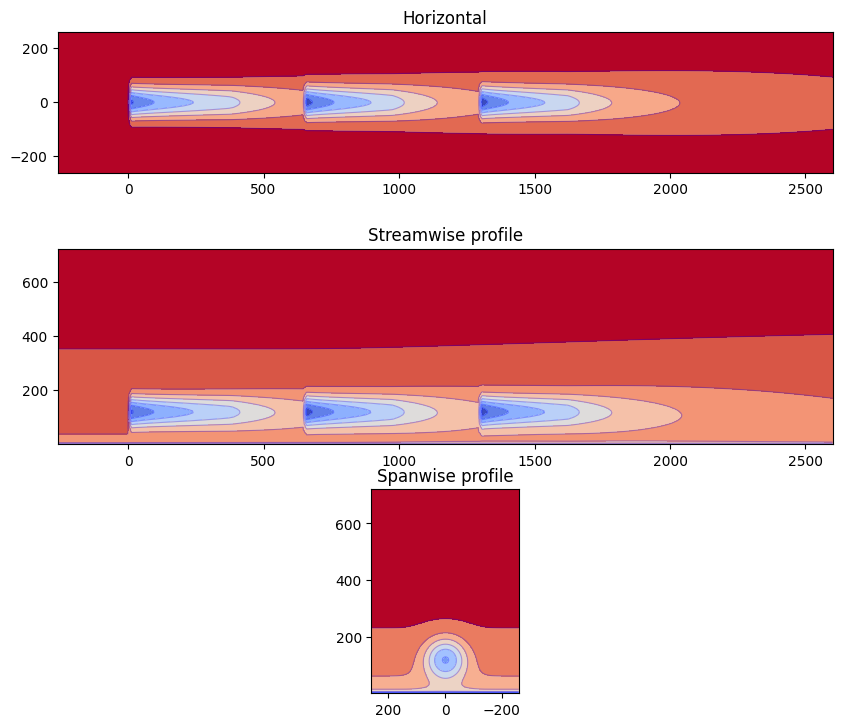

In [39]:
# Using the FlorisModel functions for generating plots, run FLORIS
# and extract 2D planes of data.
horizontal_plane = fmodel_day.calculate_horizontal_plane(x_resolution=200, y_resolution=100, height=Hub_Height)
y_plane = fmodel_day.calculate_y_plane(x_resolution=200, z_resolution=100, crossstream_dist=0.0)
cross_plane = fmodel_day.calculate_cross_plane(
    y_resolution=100, z_resolution=100, downstream_dist=500.0
)

# Create the plots
fig, ax_list = plt.subplots(3, 1, figsize=(10, 9))
ax_list = ax_list.flatten()
flowviz.visualize_cut_plane(horizontal_plane, ax=ax_list[0], title="Horizontal")
flowviz.visualize_cut_plane(y_plane, ax=ax_list[1], title="Streamwise profile")
flowviz.visualize_cut_plane(cross_plane, ax=ax_list[2], title="Spanwise profile")

#### Night

<Axes: title={'center': 'Spanwise profile'}>

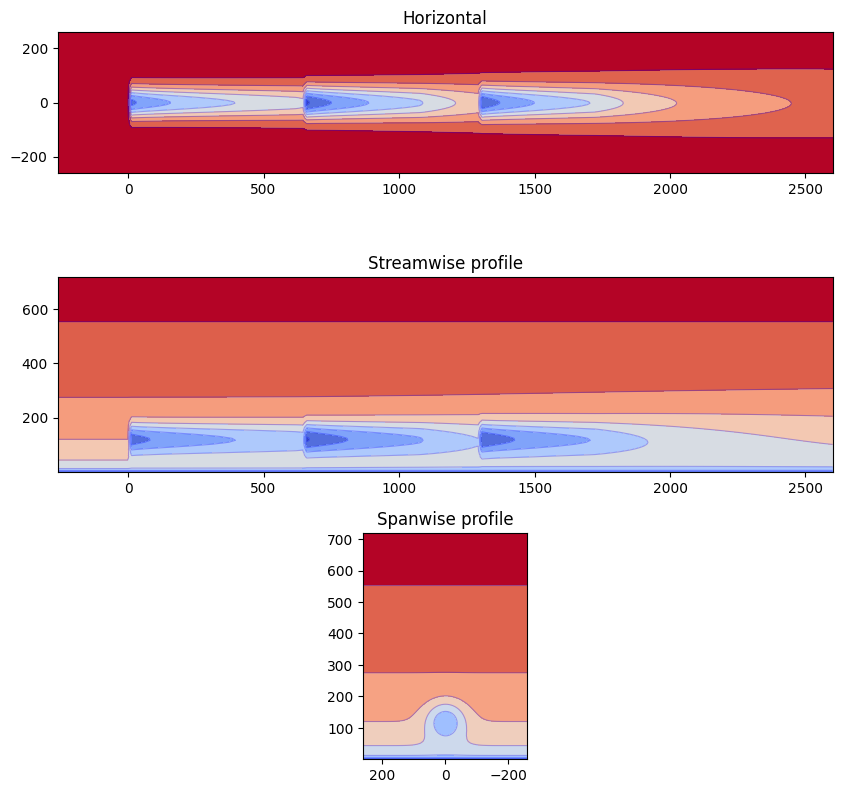

In [40]:
# Using the FlorisModel functions for generating plots, run FLORIS
# and extract 2D planes of data.
horizontal_plane = fmodel_night.calculate_horizontal_plane(x_resolution=200, y_resolution=100, height=Hub_Height)
y_plane = fmodel_night.calculate_y_plane(x_resolution=200, z_resolution=100, crossstream_dist=0.0)
cross_plane = fmodel_night.calculate_cross_plane(
    y_resolution=100, z_resolution=100, downstream_dist=500.0
)

# Create the plots
fig, ax_list = plt.subplots(3, 1, figsize=(10, 10))
ax_list = ax_list.flatten()
flowviz.visualize_cut_plane(horizontal_plane, ax=ax_list[0], title="Horizontal")
flowviz.visualize_cut_plane(y_plane, ax=ax_list[1], title="Streamwise profile")
flowviz.visualize_cut_plane(cross_plane, ax=ax_list[2], title="Spanwise profile")

<Axes: title={'center': 'Spanwise profile'}>

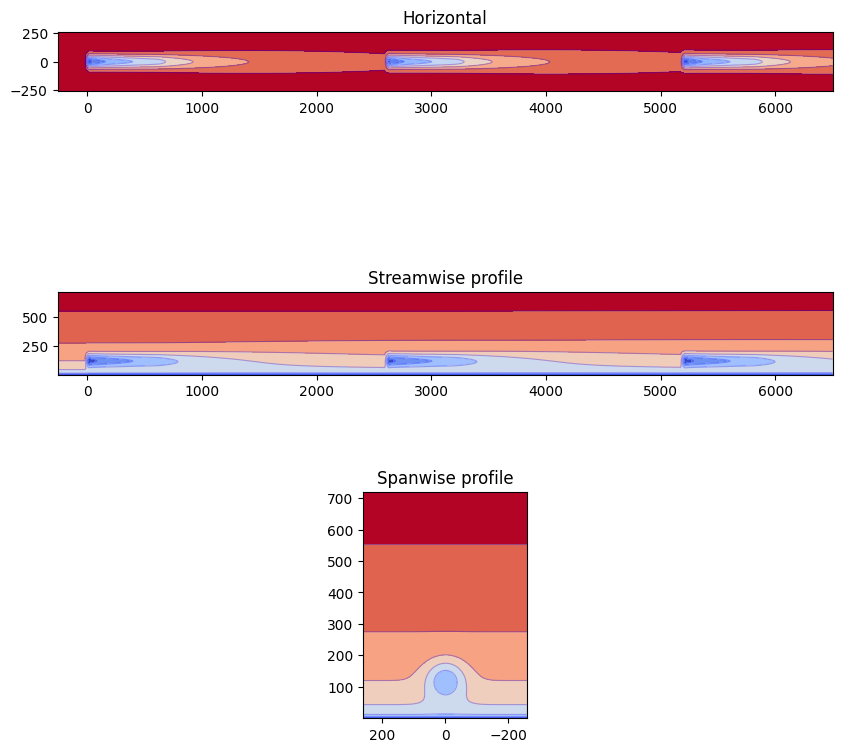

In [41]:
# Using the FlorisModel functions for generating plots, run FLORIS
# and extract 2D planes of data.
horizontal_plane = fmodel_night_10D.calculate_horizontal_plane(x_resolution=200, y_resolution=100, height=Hub_Height)
y_plane = fmodel_night_10D.calculate_y_plane(x_resolution=200, z_resolution=100, crossstream_dist=0.0)
cross_plane = fmodel_night_10D.calculate_cross_plane(
    y_resolution=100, z_resolution=100, downstream_dist=500.0
)

# Create the plots
fig, ax_list = plt.subplots(3, 1, figsize=(10, 10))
ax_list = ax_list.flatten()
flowviz.visualize_cut_plane(horizontal_plane, ax=ax_list[0], title="Horizontal")
flowviz.visualize_cut_plane(y_plane, ax=ax_list[1], title="Streamwise profile")
flowviz.visualize_cut_plane(cross_plane, ax=ax_list[2], title="Spanwise profile")

# Random Testing

<Axes: title={'center': 'Spanwise profile'}>

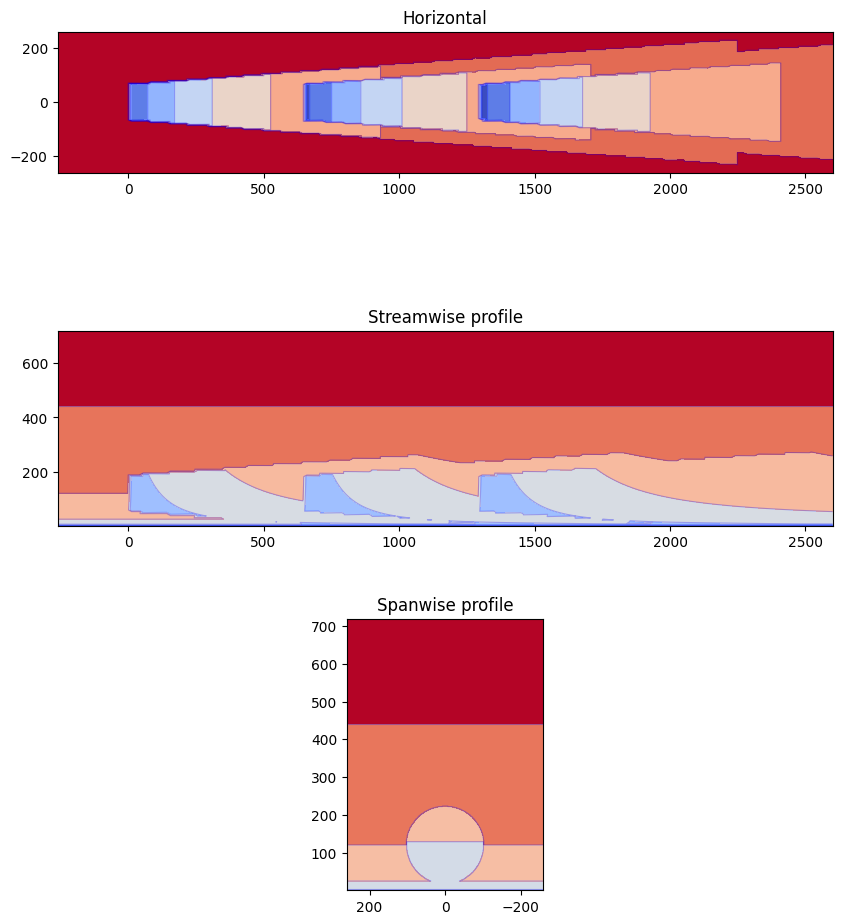

In [44]:
x = [0, 5*Rotor_Diameter, 10*Rotor_Diameter]
y = [0,0,0]
ws = [7.5]
wd = [270]
ti = [0.06]

fmodel2 = FlorisModel('/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment3/jensen2.yaml')
fmodel2.set(layout_x=x, layout_y=y,wind_directions=wd,wind_speeds=ws,
           turbulence_intensities=ti, wind_shear=windshear, solver_settings={"type": "turbine_grid", "turbine_grid_points" : 500}
           )

# Using the FlorisModel functions for generating plots, run FLORIS
# and extract 2D planes of data.
horizontal_plane = fmodel2.calculate_horizontal_plane(x_resolution=200, y_resolution=100, height=Hub_Height)
y_plane = fmodel2.calculate_y_plane(x_resolution=200, z_resolution=100, crossstream_dist=0.0)
cross_plane = fmodel2.calculate_cross_plane(
    y_resolution=500, z_resolution=500, downstream_dist=500.0
)

# Create the plots
fig, ax_list = plt.subplots(3, 1, figsize=(10, 12))
ax_list = ax_list.flatten()
flowviz.visualize_cut_plane(horizontal_plane, ax=ax_list[0], title="Horizontal")
flowviz.visualize_cut_plane(y_plane, ax=ax_list[1], title="Streamwise profile")
flowviz.visualize_cut_plane(cross_plane, ax=ax_list[2], title="Spanwise profile")